# **Analysis of glycan utilization of Catenibacterium strains**

## **Setup**

In [1]:
import os

conda_env = os.environ.get('CONDA_DEFAULT_ENV')
print('conda env:',conda_env)

os.chdir("/shares/CIBIO-Storage/CM/scratch/users/sebastiaan.valkiers/wnw")

print(os.getcwd())

conda env: wnw
/shares/CIBIO-Storage/CM/scratch/users/sebastiaan.valkiers/wnw


In [70]:
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import locale
import statsmodels.formula.api as smf

from statsmodels.stats.multitest import multipletests

mpl.rcParams["svg.fonttype"] = "none"

## **Prepare data for modeling**

In [50]:
cols = ['ODmax-ODi', 'replicate', 'experiment', 'date', 'cello (+)',
       'Y basal (-)', 'amypec', 'ara', 'aragal', 'araxyl', 'Y cellu', 'Y chi',
       'Y chito', 'fos', 'fructose', 'fuclac', 'gal', 'galman', 'Y gluman',
       'glyc', 'guar_gum', 'arabic_gum', 'Y xan_gum', 'ghatti_gum', 'inu',
       'lich', 'Y man_P', 'man_Y', 'muc', 'pec', 'pull', 'star_un', 'star',
       'xos_B', 'xos_C', 'Bgluc_O', 'Bgluc_Y']

tride = pd.read_table("./revision/cate_trid_odmaxodi.tsv")
mitsuo_t = pd.read_table("./revision/cate_mitsuo_T_odmaxodi.tsv")
mitsuo_i = pd.read_table("./revision/cate_mitsuo_isolate_odmaxodi.tsv")

tride.columns = cols
mitsuo_t.columns = cols
mitsuo_i.columns = cols

cols_to_select = ['replicate', 'experiment', 'date', 'cello (+)',
       'Y basal (-)', 'amypec', 'ara', 'aragal', 'araxyl', 'Y cellu', 'fos', 'fructose', 'gal', 'galman', 'Y gluman',
       'inu','Y man_P', 'pec', 'star_un', 'star', 'xos_B', 'xos_C', 'Bgluc_O','strain']

tride["strain"] = "tride"
mitsuo_t["strain"] = "mitsuo_T"
mitsuo_i["strain"] = "mitsuo_isolate"

df_glycans = pd.concat([tride,mitsuo_t,mitsuo_i])
df_glycans = df_glycans[cols_to_select]

cols_renamed = ['replicate', 'experiment', 'date', 'cello (+)',
       'Y basal (-)', 'amypec', 'ara', 'aragal', 'araxyl', 'cellu', 'fos', 'fructose', 'gal', 'galman', 'gluman',
       'inu','man_P', 'pec', 'star_un', 'star', 'xos_B', 'xos_C', 'Bgluc_O', 'strain']

df_glycans.columns = cols_renamed

glycan_names = pd.read_csv("./revision/glycan_abbrev.csv")
abbrev2full = dict(zip(glycan_names.name_abbrev, glycan_names.name_full))
abbrev2full["cello (+)"] = "cellobiose"

df_glycans = pd.melt(
    df_glycans,
    id_vars = ["replicate","experiment","date","strain"],
    value_name = "odmax_odi",
    var_name = "glycan_name_abbrev"
)

df_glycans["glycan_name_full"] = df_glycans.glycan_name_abbrev.apply(lambda x: abbrev2full[x] if x in abbrev2full else x)
df_glycans = df_glycans.dropna(subset=["odmax_odi"])
df_glycans["odmax_odi"] = df_glycans.odmax_odi.apply(lambda x: float(x.replace(",",".")))
df_glycans = df_glycans.drop(columns=["date"])

df_glycans.to_csv("./revision/catenibacterium_glycans.tsv", sep="\t", index=False)

## **Analysis**
Use linear model with randomized block design to estimate each glycan's OD difference from baseline, adjusting for batch (experiment).

In [71]:
DATA_PATH = "./revision/catenibacterium_glycans.tsv"
BASAL = "Y basal (-)"
ALPHA = 0.05

# Load data
df = pd.read_csv(DATA_PATH, sep="\t")
df["experiment"] = df["experiment"].astype(str)  # treat batch id as categorical

# lookup table glycan abbreviation
name_map = (
    df[["glycan_name_abbrev", "glycan_name_full"]]
    .drop_duplicates()
    .set_index("glycan_name_abbrev")["glycan_name_full"]
    .to_dict()
)

# Randomized-block-design model, one per strain, glycan vs. basal adjusted for batch
rows = []
diagnostics = {}

for strain, sub in df.groupby("strain"):
    sub = sub.copy()
    cats = [BASAL] + sorted(c for c in sub["glycan_name_abbrev"].unique() if c != BASAL)
    sub["glycan_name_abbrev"] = pd.Categorical(sub["glycan_name_abbrev"], categories=cats)

    formula = (
        f'odmax_odi ~ C(glycan_name_abbrev, Treatment(reference="{BASAL}")) '
        f"+ C(experiment)"
    )
    model = smf.ols(formula, data=sub).fit()
    diagnostics[strain] = model  # keep for residual checks below

    params, pvals, conf = model.params, model.pvalues, model.conf_int()
    for name in params.index:
        if not name.startswith("C(glycan_name_abbrev"):
            continue  # skip intercept and batch/block dummies
        glycan = name.split("T.")[-1].rstrip("]")
        n_reps = (sub["glycan_name_abbrev"] == glycan).sum()
        rows.append(
            {
                "strain": strain,
                "glycan": glycan,
                "glycan_full": name_map.get(glycan, glycan),
                "n_replicates": n_reps,
                "effect_vs_basal": params[name],   # OD units, batch-adjusted
                "ci_low": conf.loc[name, 0],
                "ci_high": conf.loc[name, 1],
                "p_raw": pvals[name],
            }
        )

results = pd.DataFrame(rows)
results["p_holm"] = results.groupby("strain")["p_raw"].transform(
    lambda p: multipletests(p, method="holm")[1]
)
results["significant"] = results["p_holm"] < ALPHA
results = results.sort_values(["strain", "effect_vs_basal"], ascending=[True, False])
results.to_csv("glycan_vs_basal_results.csv", index=False)


# Residual diagnostics (sanity-check model assumptions)
print("\n=== Residual diagnostics per strain (Shapiro-Wilk normality test) ===")
from scipy import stats as spstats

for strain, model in diagnostics.items():
    resid = model.resid
    w, p = spstats.shapiro(resid)
    print(f"{strain}: Shapiro-Wilk W={w:.3f}, p={p:.3f} "
          f"({'no strong evidence against normality' if p > 0.05 else 'residuals deviate from normal - interpret p-values cautiously'})")

# Descriptive, batch-matched normalization (for plotting only)
#    - net OD  = glycan_OD - mean(basal OD in same strain+batch)
#    - fold    = glycan_OD / mean(basal OD in same strain+batch)
#    Batches with no basal replicate (tride/experiment 5) fall back to
#    that strain's pooled basal mean across its other batches, and are
#    flagged.
basal_by_batch = (
    df[df["glycan_name_abbrev"] == BASAL]
    .groupby(["strain", "experiment"])["odmax_odi"]
    .mean()
    .rename("basal_batch_mean")
)
basal_by_strain = (
    df[df["glycan_name_abbrev"] == BASAL]
    .groupby("strain")["odmax_odi"]
    .mean()
    .rename("basal_strain_mean")
)

norm = df.merge(basal_by_batch, on=["strain", "experiment"], how="left")
norm = norm.merge(basal_by_strain, on="strain", how="left")
norm["basal_used"] = norm["basal_batch_mean"].fillna(norm["basal_strain_mean"])
norm["basal_imputed"] = norm["basal_batch_mean"].isna()
norm["net_od"] = norm["odmax_odi"] - norm["basal_used"]
norm["fold_change"] = norm["odmax_odi"] / norm["basal_used"]
norm.to_csv("glycan_normalized_descriptive.csv", index=False)

if norm["basal_imputed"].any():
    n_imp = norm.loc[norm["basal_imputed"], ["strain", "experiment"]].drop_duplicates()
    print(f"\nNote: batch(es) with no basal replicate, so strain-level pooled "
          f"basal mean was used instead for the descriptive net_od/fold_change "
          f"columns only (NOT for the model-based p-values above):")
    print(n_imp.to_string(index=False))



=== Residual diagnostics per strain (Shapiro-Wilk normality test) ===
mitsuo_T: Shapiro-Wilk W=0.920, p=0.000 (residuals deviate from normal - interpret p-values cautiously)
mitsuo_isolate: Shapiro-Wilk W=0.915, p=0.000 (residuals deviate from normal - interpret p-values cautiously)
tride: Shapiro-Wilk W=0.989, p=0.219 (no strong evidence against normality)

Note: batch(es) with no basal replicate, so strain-level pooled basal mean was used instead for the descriptive net_od/fold_change columns only (NOT for the model-based p-values above):
strain experiment
 tride          5


In [59]:
results.head()

,strain,glycan,glycan_full,n_replicates,effect_vs_basal,ci_low,ci_high,p_raw,p_holm,significant
5,mitsuo_T,cello (+),cellobiose,15,0.414140,0.359500,0.468780,4.228351e-27,8.033866e-26,True
8,mitsuo_T,fructose,fructose,5,0.338470,0.252076,0.424864,8.018244e-12,1.443284e-10,True
7,mitsuo_T,fos,Fructooligosaccharides,5,0.195470,0.109076,0.281864,1.960063e-05,2.548082e-04,True
11,mitsuo_T,gluman,Glucomannan (4C),4,0.079825,-0.012822,0.172472,9.045524e-02,7.236419e-01,False
0,mitsuo_T,Bgluc_O,β-glucan_oat,5,0.045690,-0.040704,0.132084,2.964948e-01,1.000000e+00,False


In [58]:
results.to_csv("./revision/RBD_linear_model_results.tsv", index=False, sep="\t")

## **Plotting**
Visualize data in a forest plot. Show significant effects as bright colors. Values that did not reach significance get a faint color.

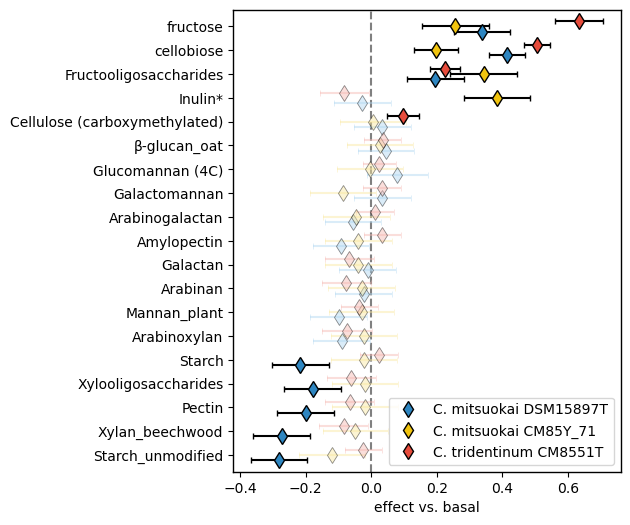

In [69]:
strain2name = {
    'mitsuo_T':'C. mitsuokai DSM15897T',
    'mitsuo_isolate':'C. mitsuokai CM85Y_71',
    'tride':'C. tridentinum CM8551T'
}

df = pd.read_csv('./revision/RBD_linear_model_results.tsv', sep='\t')
df["strain"] = df["strain"].map(strain2name)

strains = ['C. mitsuokai DSM15897T', 'C. mitsuokai CM85Y_71', 'C. tridentinum CM8551T']

# order glycans by mean effect across strains (descending), like a typical forest plot
order = (df.groupby('glycan_full')['effect_vs_basal']
           .mean().sort_values(ascending=False).index.tolist())

n = len(order)
y_pos = np.arange(n)

# offsets so the 3 strains stack under each other within each glycan row
offsets = {strains[0]: 0.22, strains[1]: 0.0, strains[2]: -0.22}

# base (faint) pastel colors -- same family as the reference plot
faint_colors = {
    'C. mitsuokai DSM15897T':       "#AED6F1",  # light blue
    'C. mitsuokai CM85Y_71': "#F9E79F",  # light yellow
    'C. tridentinum CM8551T':          "#F5B7B1",  # light pink/red
}
# saturated (popping) versions of the same hues, for significant points
pop_colors = {
    'C. mitsuokai DSM15897T':       "#2E86C1",  # strong blue
    'C. mitsuokai CM85Y_71': "#F1C40F",  # strong gold
    'C. tridentinum CM8551T':          "#E74C3C",  # strong red
}

fig, ax = plt.subplots(figsize=(5,6))

for strain in strains:
    sub = df[df['strain'] == strain].set_index('glycan_full').reindex(order)
    y = y_pos + offsets[strain]

    x = sub['effect_vs_basal'].values
    lo = (sub['effect_vs_basal'] - sub['ci_low']).values
    hi = (sub['ci_high'] - sub['effect_vs_basal']).values
    sig = sub['significant'].values

    # non-significant: faint pastel, low alpha
    mask_ns = ~sig
    if mask_ns.any():
        ax.errorbar(
            x=x[mask_ns], y=y[mask_ns], xerr=[lo[mask_ns], hi[mask_ns]],
            fmt='d', markersize=8,
            markerfacecolor=faint_colors[strain], alpha=0.45,
            ecolor=faint_colors[strain], capsize=2,
            mec='k', mew=0.6,
        )

    # significant: saturated, fully opaque, pops out
    mask_s = sig
    if mask_s.any():
        ax.errorbar(
            x=x[mask_s], y=y[mask_s], xerr=[lo[mask_s], hi[mask_s]],
            fmt='d', markersize=8,
            markerfacecolor=pop_colors[strain], alpha=1.0,
            ecolor='k', capsize=2,
            mec='k', mew=1.0,
        )

    # one dummy handle per strain for a clean legend (using the pop color)
    ax.errorbar([], [], fmt='d', markersize=8, markerfacecolor=pop_colors[strain],
                mec='k', mew=1.0, ecolor='k', label=strain)

ax.axvline(0, ls='--', color='gray', zorder=0)
ax.set_yticks(y_pos)
ax.set_yticklabels(order)
ax.set_ylim(-0.7, n - 1 + 0.7)
ax.invert_yaxis()
ax.set_xlabel('effect vs. basal')
ax.legend(frameon=True)

for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color('black')
    spine.set_linewidth(1.0)

# plt.tight_layout()
plt.savefig('./revision/RBD_forest_plot.svg', bbox_inches='tight')